## Setup ViT-Pose Model

In [13]:
# %% 2. Setup ViT-Pose Model (CPU Mode - Safe Fallback)
import os
import cv2
import json
import torch
from pathlib import Path
from mmpose.apis import init_model, inference_topdown
from mmpose.utils import register_all_modules
from mim import download

register_all_modules()

# --- Config & Paths ---
def get_project_root():
    current_path = Path().cwd()
    for parent in [current_path] + list(current_path.parents):
        if (parent / ".git").exists() or (parent / "requirements.txt").exists():
            return parent
    return current_path

PROJECT_ROOT = get_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
NEW_DATA_DIR = DATA_ROOT / "pseudo_labels" / "train"
JSON_PATH = NEW_DATA_DIR / "_annotations.coco.json" 
HYBRID_JSON_PATH = NEW_DATA_DIR / "hybrid_train.json"

MODEL_DIR = PROJECT_ROOT / "models" / "vitpose_base"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# --- Auto-Download via MIM ---
model_name = "td-hm_ViTPose-base-simple_8xb64-210e_coco-256x192"
print(f"⬇️ Downloading {model_name} via MIM...")
checkpoint_name = download(
    package="mmpose", 
    configs=[model_name], 
    dest_root=str(MODEL_DIR)
)[0]

CFG_PATH = MODEL_DIR / (model_name + ".py")
CKPT_PATH = MODEL_DIR / checkpoint_name

# --- Init Model on CPU ---
# We force CPU to avoid "no kernel image" errors on RTX 5060 with old PyTorch
device = 'cpu' 
print(f"⚠️ FORCE CPU MODE: Running on {device} to bypass CUDA compatibility issues.")

try:
    pose_model = init_model(str(CFG_PATH), str(CKPT_PATH), device=device)
    print("✅ Model Loaded Successfully on CPU.")
except Exception as e:
    print("\n❌ Error loading model.")
    if CFG_PATH.exists(): os.remove(CFG_PATH)
    if CKPT_PATH.exists(): os.remove(CKPT_PATH)
    raise e

⬇️ Downloading td-hm_ViTPose-base-simple_8xb64-210e_coco-256x192 via MIM...
processing td-hm_ViTPose-base-simple_8xb64-210e_coco-256x192...
td-hm_ViTPose-base-simple_8xb64-210e_coco-256x192-0b8234ea_20230407.pth exists in /home/cooper/Desktop/My Personal/Repositories/Boxer-Pose-Estimation/models/vitpose_base
Successfully dumped td-hm_ViTPose-base-simple_8xb64-210e_coco-256x192.py to /home/cooper/Desktop/My Personal/Repositories/Boxer-Pose-Estimation/models/vitpose_base
⚠️ FORCE CPU MODE: Running on cpu to bypass CUDA compatibility issues.
Loads checkpoint by local backend from path: /home/cooper/Desktop/My Personal/Repositories/Boxer-Pose-Estimation/models/vitpose_base/td-hm_ViTPose-base-simple_8xb64-210e_coco-256x192-0b8234ea_20230407.pth
The model and loaded state dict do not match exactly

unexpected key in source state_dict: backbone.cls_token

✅ Model Loaded Successfully on CPU.


## Define Conversion Logic

In [6]:
def convert_kpts_coco17_to_custom14(kpts, confs):
    """
    Input: kpts (17, 2), confs (17,)
    Output: list [x, y, v, x, y, v...] (length 42)
    """
    # Indices: 0:Nose, 5:L_Sho, 6:R_Sho, 7:L_Elb, 8:R_Elb, 9:L_Wri, 10:R_Wri, 11:L_Hip, 12:R_Hip, 13:L_Knee, 14:R_Knee, 15:L_Ank, 16:R_Ank
    
    # Calculate Neck (Midpoint of Shoulders)
    l_sho, r_sho = kpts[5], kpts[6]
    neck_xy = (l_sho + r_sho) / 2.0
    neck_conf = min(confs[5], confs[6])

    # Custom Order: Nose, Neck, L_Sho, R_Sho, L_Elb, R_Elb, L_Wri, R_Wri, L_Hip, R_Hip, L_Knee, R_Knee, L_Ank, R_Ank
    custom_ordered_indices = [0, None, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
    
    flat_list = []
    for idx in custom_ordered_indices:
        if idx is None: # Neck
            x, y = neck_xy
            c = neck_conf
        else:
            x, y = kpts[idx]
            c = confs[idx]
            
        # Visibility: 2 (visible), 1 (labeled/hidden), 0 (missing)
        v = 2 if c > 0.4 else 0 
        flat_list.extend([float(x), float(y), int(v)])
        
    return flat_list

## Visualization (Sanity Check)

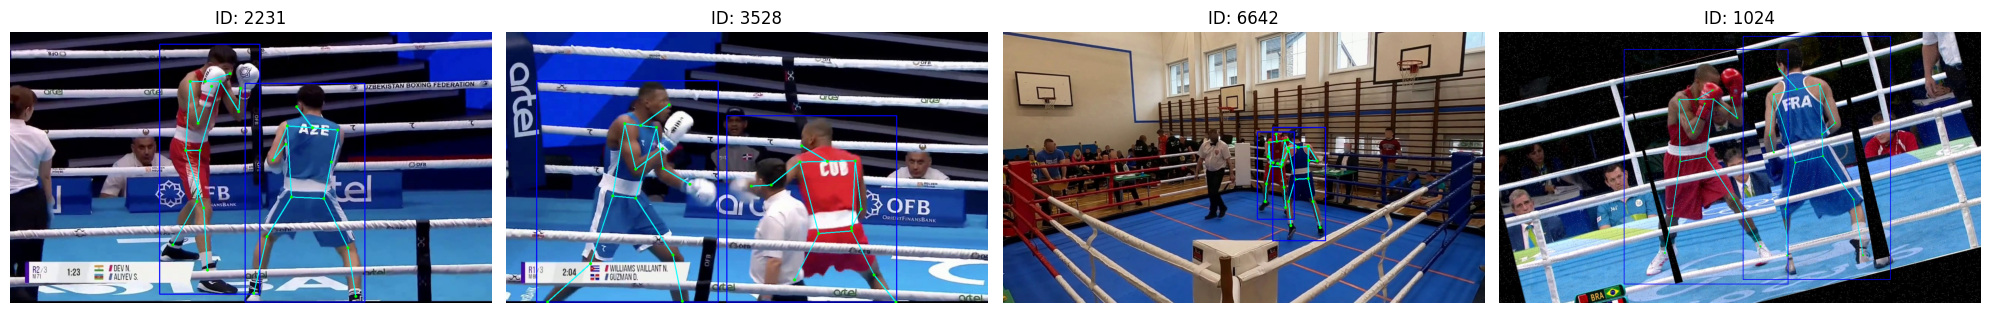

In [18]:
import random
import matplotlib.pyplot as plt

# --- Define Skeleton Connections (Indices for Custom 14 Format) ---
# 0:Nose, 1:Neck, 2:LSho, 3:RSho, 4:LElb, 5:RElb, 6:LWri, 7:RWri, 
# 8:LHip, 9:RHip, 10:LKnee, 11:RKnee, 12:LAnk, 13:RAnk
SKELETON_PAIRS = [
    (0, 1),           # Nose -> Neck
    (1, 2), (1, 3),   # Neck -> Shoulders
    (2, 4), (4, 6),   # Left Arm
    (3, 5), (5, 7),   # Right Arm
    (2, 8), (3, 9),   # Torso (Shoulders -> Hips)
    (8, 9),           # Hip connection
    (8, 10), (10, 12),# Left Leg
    (9, 11), (11, 13) # Right Leg
]

# Load Annotations
with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

# Maps
img_map = {img['id']: img for img in coco_data['images']}
ann_map = {}
for ann in coco_data['annotations']:
    ann_map.setdefault(ann['image_id'], []).append(ann)

# Select Samples
sample_ids = random.sample(list(ann_map.keys()), 4)
plt.figure(figsize=(20, 10))

for i, img_id in enumerate(sample_ids):
    img_info = img_map[img_id]
    
    # Path Logic (Robust check)
    img_path = NEW_DATA_DIR / "images" / img_info['file_name']
    if not img_path.exists():
        img_path = NEW_DATA_DIR / "images" / Path(img_info['file_name']).name
    
    if not img_path.exists():
        print(f"Missing: {img_path}")
        continue

    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Prepare GT Boxes
    gt_anns = ann_map[img_id]
    box_inputs = [] 
    
    for ann in gt_anns:
        x, y, w, h = ann['bbox']
        box_inputs.append([x, y, x+w, y+h])

    # RUN INFERENCE
    results = inference_topdown(
        pose_model,
        str(img_path),
        bboxes=box_inputs, 
        bbox_format='xyxy'
    )
    
    # Draw
    for idx, res in enumerate(results):
        kpts = res.pred_instances.keypoints[0]
        confs = res.pred_instances.keypoint_scores[0] # Note: keypoint_scores (singular)
        
        # Draw GT Box
        bx = box_inputs[idx]
        cv2.rectangle(img_rgb, (int(bx[0]), int(bx[1])), (int(bx[2]), int(bx[3])), (0, 0, 255), 2)
        
        # Get Custom 14 Format
        custom_flat = convert_kpts_coco17_to_custom14(kpts, confs)
        
        # 1. DRAW LINES (SKELETON) FIRST
        for p1, p2 in SKELETON_PAIRS:
            # Indices in flat list: k*3 for x, k*3+1 for y, k*3+2 for visibility
            idx1, idx2 = p1 * 3, p2 * 3
            x1, y1, v1 = custom_flat[idx1], custom_flat[idx1+1], custom_flat[idx1+2]
            x2, y2, v2 = custom_flat[idx2], custom_flat[idx2+1], custom_flat[idx2+2]
            
            # Only draw if both points are visible/labeled
            if v1 > 0 and v2 > 0:
                cv2.line(img_rgb, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 255), 2) # Cyan Lines

        # 2. DRAW KEYPOINTS (CIRCLES) ON TOP
        for k in range(0, len(custom_flat), 3):
            kx, ky, v = custom_flat[k], custom_flat[k+1], custom_flat[k+2]
            if v > 0:
                cv2.circle(img_rgb, (int(kx), int(ky)), 4, (0, 255, 0), -1) # Green Dots

    plt.subplot(1, 4, i+1)
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f"ID: {img_id}")

plt.tight_layout()
plt.show()

## Full Dataset Generation

In [ ]:
import tqdm

print(f"🚀 Starting Full Generation on {len(coco_data['images'])} images...")

hybrid_annotations = []
new_ann_id = 1

# Process Loop
for img_info in tqdm(coco_data['images']):
    img_id = img_info['id']
    img_path = NEW_DATA_DIR / Path(img_info['file_name']).name
    
    if not img_path.exists(): continue
        
    # Get GT Boxes
    gt_anns = ann_map.get(img_id, [])
    if not gt_anns: continue
    
    # Prepare Input Boxes for ViTPose
    box_inputs = []
    for ann in gt_anns:
        x, y, w, h = ann['bbox']
        box_inputs.append([x, y, x+w, y+h]) # xyxy
        
    # Run Teacher Inference
    try:
        results = inference_topdown(
            pose_model,
            str(img_path),
            box_inputs,
            bbox_format='xyxy'
        )
    except Exception as e:
        print(f"Error on {img_id}: {e}")
        continue

    # Merge Results
    for idx, res in enumerate(results):
        kpts = res.pred_instances.keypoints[0]
        confs = res.pred_instances.keypoints_scores[0]
        
        # Convert Poses
        final_kpts = convert_kpts_coco17_to_custom14(kpts, confs)
        
        # Create New Annotation
        # We reuse the GT info (Category, BBox, Area) but inject new Keypoints
        original_ann = gt_anns[idx]
        
        new_ann = {
            "id": new_ann_id,
            "image_id": img_id,
            "category_id": original_ann['category_id'], # Keep original Class (Red/Blue)
            "bbox": original_ann['bbox'],               # Keep original Box
            "area": original_ann['area'],
            "iscrowd": original_ann.get('iscrowd', 0),
            "num_keypoints": 14,
            "keypoints": final_kpts,
            "segmentation": []
        }
        hybrid_annotations.append(new_ann)
        new_ann_id += 1

# Save Final JSON
coco_data['annotations'] = hybrid_annotations

# Ensure Categories are correct in metadata
coco_data['categories'] = [
    {
        "id": 1, "name": "boxer_red", "supercategory": "person", 
        "keypoints": ["left_shoulder", "right_shoulder", "left_hip", "right_hip", "left_knee", "right_knee", "left_ankle", "right_ankle", "left_elbow", "left_wrist", "right_elbow", "right_wrist", "neck", "nose"],
        "skeleton": [[9, 10], [1, 3], [2, 4], [1, 2], [3, 4], [6, 8], [4, 6], [5, 7], [11, 12], [14, 13], [1, 13], [13, 2], [2, 11], [1, 9], [3, 5]]
    },
    {
        "id": 2, "name": "boxer_blue", "supercategory": "person",
        "keypoints": ["left_shoulder", "right_shoulder", "left_hip", "right_hip", "left_knee", "right_knee", "left_ankle", "right_ankle", "left_elbow", "left_wrist", "right_elbow", "right_wrist", "neck", "nose"],
        "skeleton": [[9, 10], [1, 3], [2, 4], [1, 2], [3, 4], [6, 8], [4, 6], [5, 7], [11, 12], [14, 13], [1, 13], [13, 2], [2, 11], [1, 9], [3, 5]]
    }
]

with open(HYBRID_JSON_PATH, 'w') as f:
    json.dump(coco_data, f)

print(f"✅ Saved Hybrid Dataset with {len(hybrid_annotations)} annotations to: {HYBRID_JSON_PATH}")